In [10]:
import pandas
import numpy
from energiapy.components.temporal_scale import TemporalScale
from energiapy.components.resource import Resource, VaryingResource
from energiapy.components.process import Process, VaryingProcess
from energiapy.components.material import Material
from energiapy.components.location import Location
from energiapy.components.network import Network
from energiapy.components.scenario import Scenario
from energiapy.components.transport import Transport
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX
from energiapy.model.solve import solve
from itertools import product

from energiapy.components.result import Result
import pandas
from itertools import product
from matplotlib import rc
import matplotlib.pyplot as plt
from energiapy.model.solve import solve
from energiapy.plot.plot_results import CostY, CostX
from energiapy.components.location import Location
from energiapy.plot import plot_results, plot_scenario
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.model.bounds import CapacityBounds
from energiapy.utils.data_utils import get_data, make_henry_price_df, remove_outliers, load_results
from energiapy.components.transport import Transport
from energiapy.components.scenario import Scenario
from energiapy.components.network import Network
from energiapy.components.location import Location
from energiapy.components.material import Material

from energiapy.conversion.photovoltaic import solar_power_output
from energiapy.conversion.windmill import wind_power_output

from energiapy.utils.data_utils import load_results
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX

ModuleNotFoundError: No module named 'energiapy'

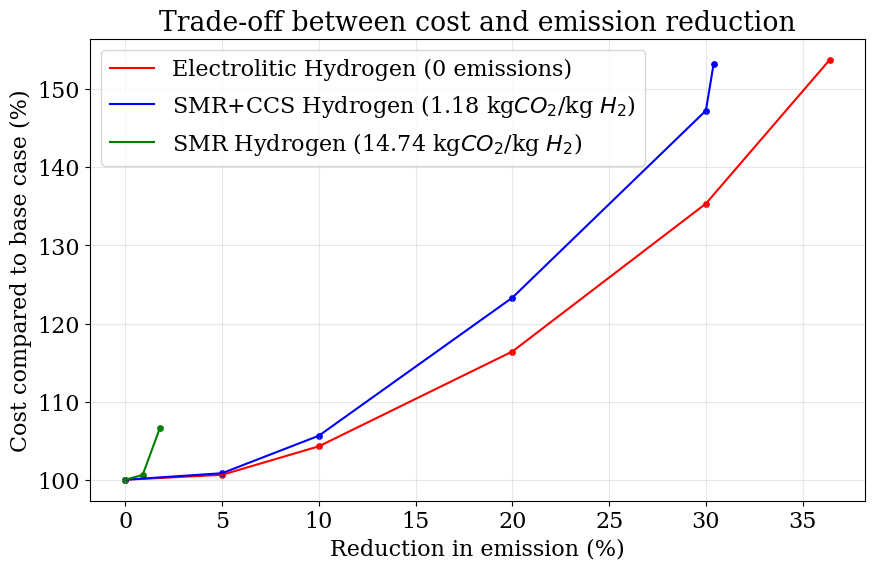

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 100.62575109000296, 104.27337079261932, 116.41573970352088, 135.34756498087938, 153.77235911186392],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'red',
        'label': 'Electrolitic Hydrogen (0 emissions)'
    },
    {
        'y_': [100.0, 100.83256795296175, 105.62998562823492, 123.30650880541889, 147.26239898283708, 153.25948918058805],
        'x_': [0, 5, 10 , 20, 30, 30.4],
        'color': 'blue',
        'label': 'SMR+CCS Hydrogen (1.18 kg$CO_2$/kg $H_2$)'
    },
    {
        'y_': [99.99999999999999, 100.61356877397935, 106.67028313504406],
        'x_': [0, 0.9, 1.8],
        'color': 'green',
        'label': 'SMR Hydrogen (14.74 kg$CO_2$/kg $H_2$)'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



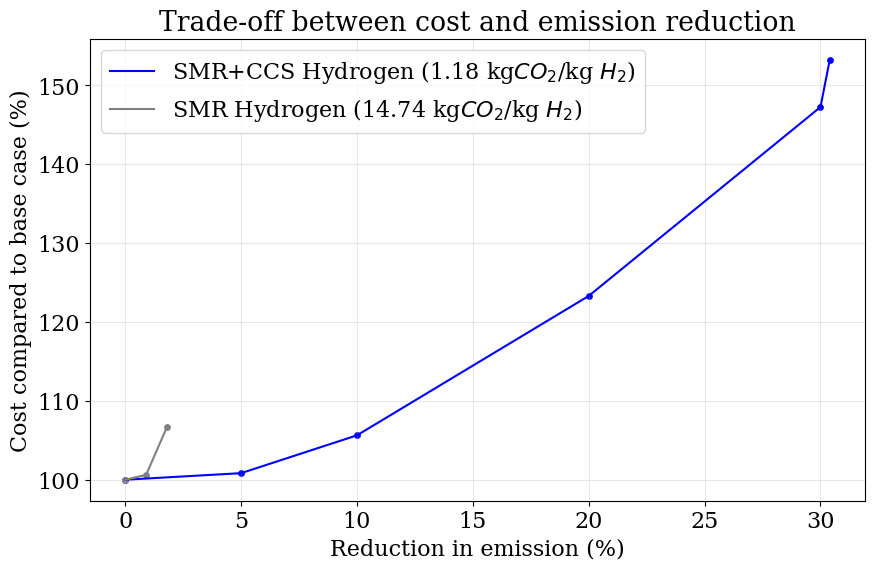

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 100.83256795296175, 105.62998562823492, 123.30650880541889, 147.26239898283708, 153.25948918058805],
        'x_': [0, 5, 10 , 20, 30, 30.4],
        'color': 'blue',
        'label': 'SMR+CCS Hydrogen (1.18 kg$CO_2$/kg $H_2$)'
    },
    {
        'y_': [99.99999999999999, 100.61356877397935, 106.67028313504406],
        'x_': [0, 0.9, 1.8],
        'color': 'grey',
        'label': 'SMR Hydrogen (14.74 kg$CO_2$/kg $H_2$)'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



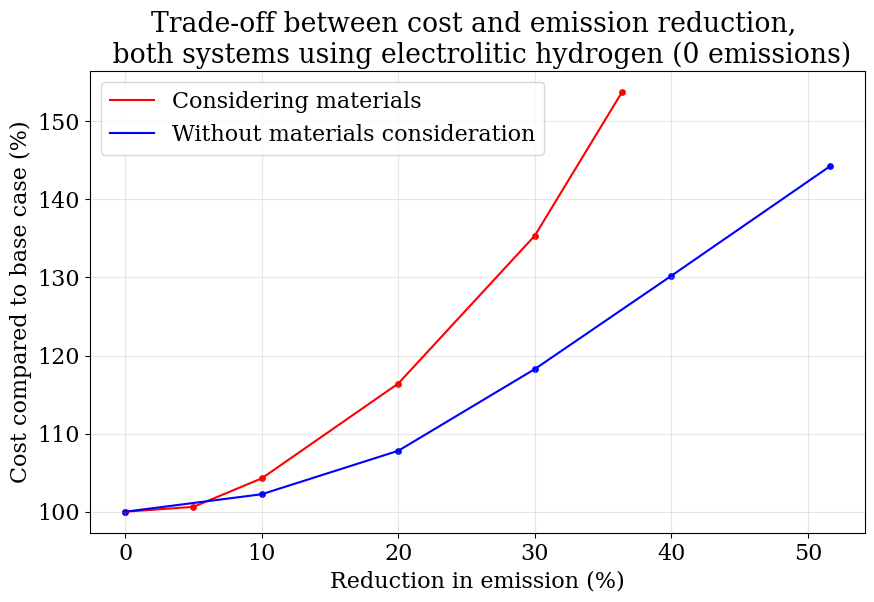

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 100.62575109000296, 104.27337079261932, 116.41573970352088, 135.34756498087938, 153.77235911186392],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'red',
        'label': 'Considering materials'
    },
    {
        'y_': [100.0, 102.24042881768236, 107.80439071853183, 118.2672704902458, 130.2078706931662, 144.21182606303086],
        'x_': [0, 10, 20, 30, 40, 51.6],
        'color': 'blue',
        'label': 'Without materials consideration'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction, \n both systems using electrolitic hydrogen (0 emissions)')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


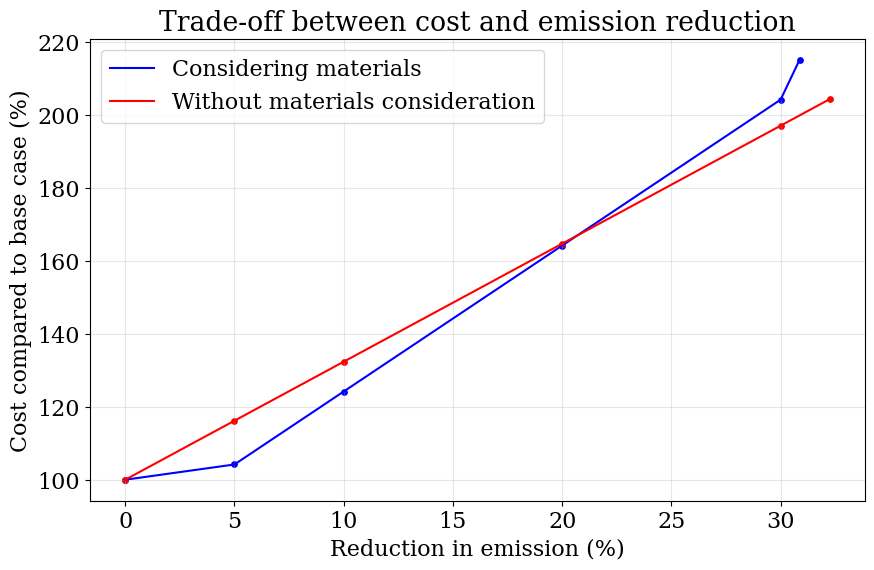

: 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.18047898489043, 124.18774662587641, 164.20228190779136, 204.21681718988242, 215.16792325277981],
        'x_': [0, 5, 10, 20, 30, 30.87],
        'color': 'blue',
        'label': 'Considering materials'
    },
    {
        'y_': [100.0, 116.18017257225733, 132.36034514443224, 164.7206902890061, 197.08103543339794, 204.37344208577116],
        'x_': [0, 5, 10, 20, 30, 32.25],
        'color': 'red',
        'label': 'Without materials consideration'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.18047898489043, 124.18774662587641, 164.20228190779136, 204.21681718988242, 215.16792325277981],
        'x_': [0, 5, 10, 20, 30, 30.87],
        'color': 'blue',
        'label': 'Considering materials'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


Sensitivity analysis with price of H2

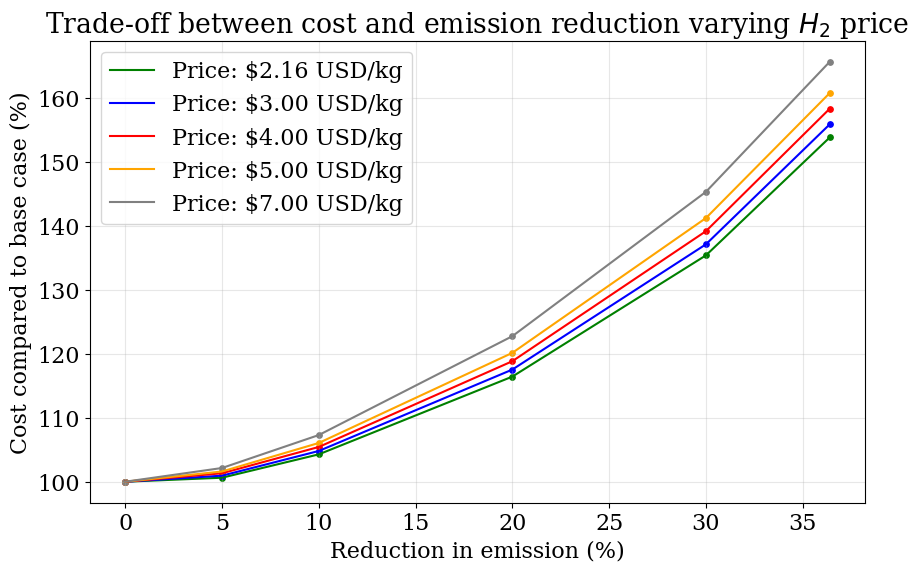

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 100.62575109000296, 104.27337079261932, 116.41573970352088, 135.34756498087938, 153.77235911186392],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'green',
        'label': 'Price: $2.16 USD/kg'
    },
    {
        'y_': [100.0, 100.94533691574028, 104.80153870737205, 117.51458595546072, 137.07364277806906, 155.82383865353867],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'blue',
        'label': 'Price: $3.00 USD/kg'
    },
    {
        'y_': [100.0, 101.320015859369, 105.42789171627788, 118.82041492732345, 139.12509472167844, 158.26607620315207],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'red',
        'label': 'Price: $4.00 USD/kg'
    },
    {
        'y_': [100.0, 101.59900856462912, 106.05213688222227, 120.12446987309471, 141.17406753230173, 160.70831375315893],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'orange',
        'label': 'Price: $5.00 USD/kg'
    },
    {
        'y_': [100.0, 102.14214728510412, 107.28765528905436, 122.72774751660863, 145.2664209614375, 165.59278885239664],
        'x_': [0, 5, 10 , 20, 30, 36.4],
        'color': 'gray',
        'label': 'Price: $7.00 USD/kg'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction varying $H_2$ price')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



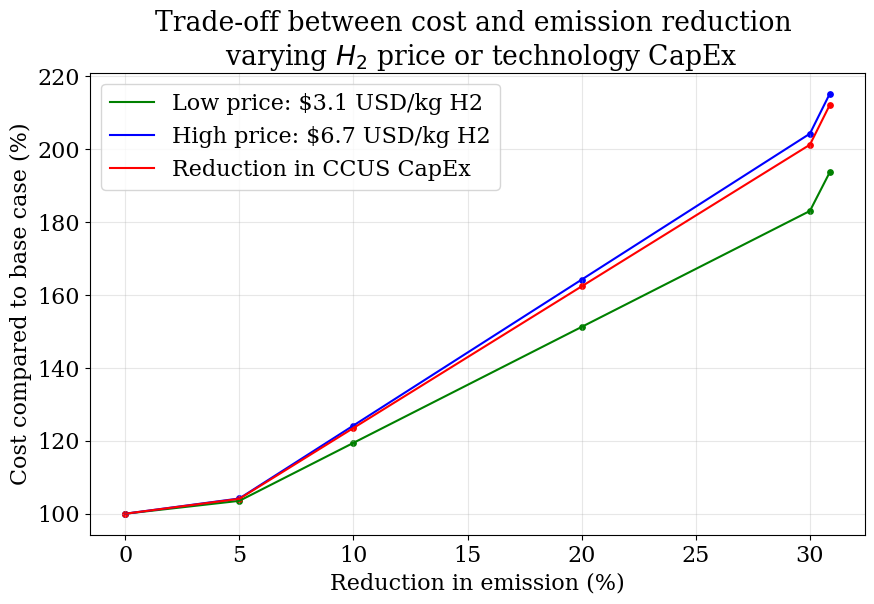

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 103.53418053427707, 119.43239069655714, 151.22881102107252, 183.02523134555662, 193.644076336375],
        'x_': [0, 5, 10, 20, 30, 30.87],
        'color': 'green',
        'label': 'Low price: $3.1 USD/kg H2'
    },
    {
        'y_': [100.00, 104.18, 124.19, 164.20, 204.22, 215.17],
        'x_': [0, 5, 10, 20, 30, 30.87],
        'color': 'blue',
        'label': 'High price: $6.7 USD/kg H2'
    },
    {   
        'y_': [100.0, 104.09044884259191, 123.51084472677452, 162.35163649543756, 201.19242826414327, 212.0928608417801],
        'x_': [0, 5, 10, 20, 30, 30.87],
        'color': 'red',
        'label': 'Reduction in CCUS CapEx'  
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n varying $H_2$ price or technology CapEx')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



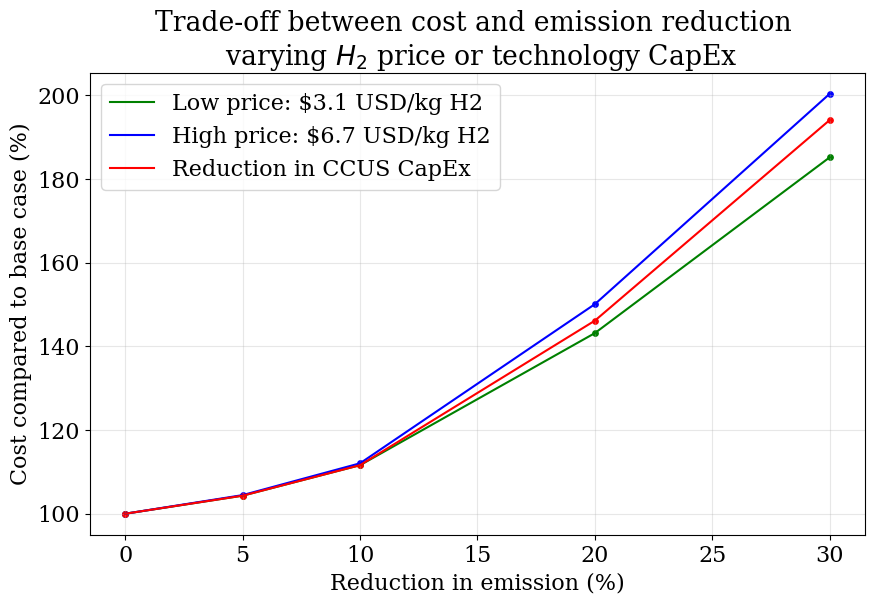

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.31609707164431, 111.60653190013231, 143.18202123404788, 185.2020301333821],
        'x_': [0, 5, 10, 20, 30],
        'color': 'green',
        'label': 'Low price: $3.1 USD/kg H2'
    },
    {
        'y_': [100.0, 104.44998565811277, 112.05613386368962, 150.09976139274255, 200.39398022244458],
        'x_': [0, 5, 10, 20, 30],
        'color': 'blue',
        'label': 'High price: $6.7 USD/kg H2'
    },
    {   
        'y_': [100.0, 104.31609707164434, 111.60653190013257, 146.15856845394364, 194.11334415998257],
        'x_': [0, 5, 10, 20, 30],
        'color': 'red',
        'label': 'Reduction in CCUS CapEx'  
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n varying $H_2$ price or technology CapEx')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_33880\120154724.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


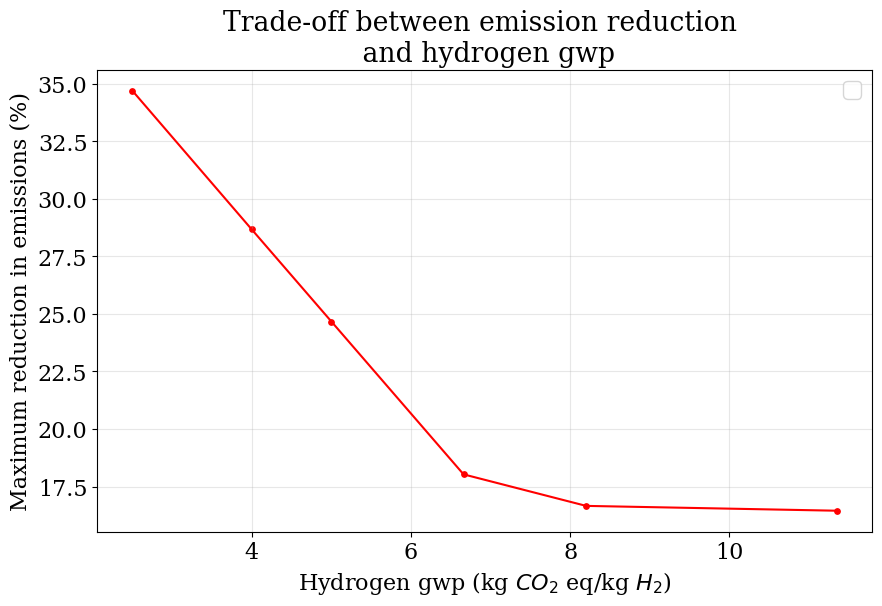

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [16.45, 16.66, 18.03, 24.67, 28.67, 34.7],
        'x_': [11.35, 8.2, 6.66, 5, 4, 2.5],
        'color': 'red',
        'label': ''
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between emission reduction \n and hydrogen gwp')
plt.ylabel('Maximum reduction in emissions (%)')
plt.xlabel('Hydrogen gwp (kg $CO_2$ eq/kg $H_2$)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


In [23]:
1.573253492937e+09/1.112433813160e+09
1.843377538000e+09/1.112433813160e+09
2.457654625774e+09/1.112433813160e+09

2.2092591907043357

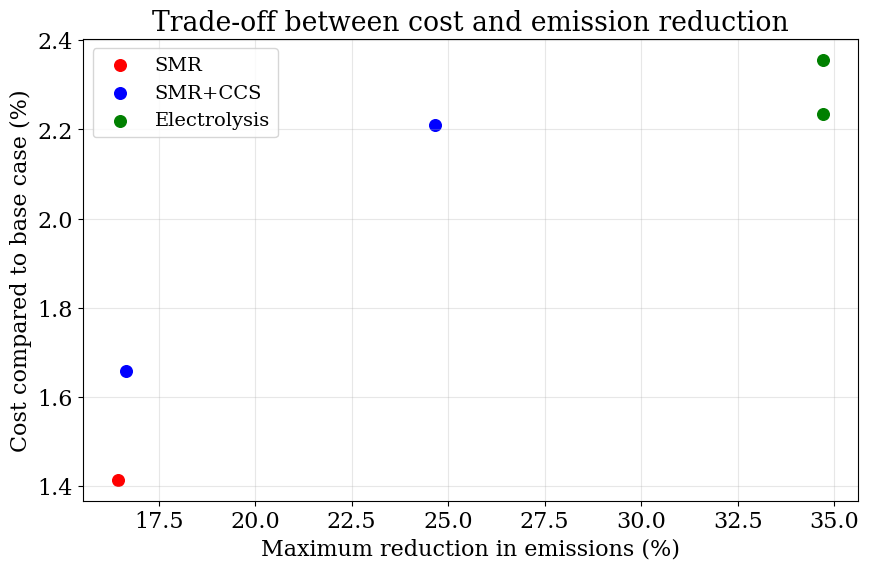

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [1.414244581857852],
        'x_': [16.45],
        'color': 'red',
        'label': 'SMR'
    },

    {
        'y_': [1.6570, 2.21],
        'x_': [16.66, 24.67],
        'color': 'blue',
        'label': 'SMR+CCS'
    },
    
    {
        'y_': [2.2343, 2.35629],
        'x_': [34.7, 34.7],
        'color': 'green',
        'label': 'Electrolysis'
    },
]

# Define unique markers for each dataset
markers = ['o', 'o', 'o']

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data, marker in zip(datasets, markers):
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=70, 
               label=data['label'], marker=marker)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Maximum reduction in emissions (%)')
plt.grid(alpha=0.3)
plt.legend(fontsize=14)
plt.rcdefaults()
plt.show()


C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_33880\4261707051.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

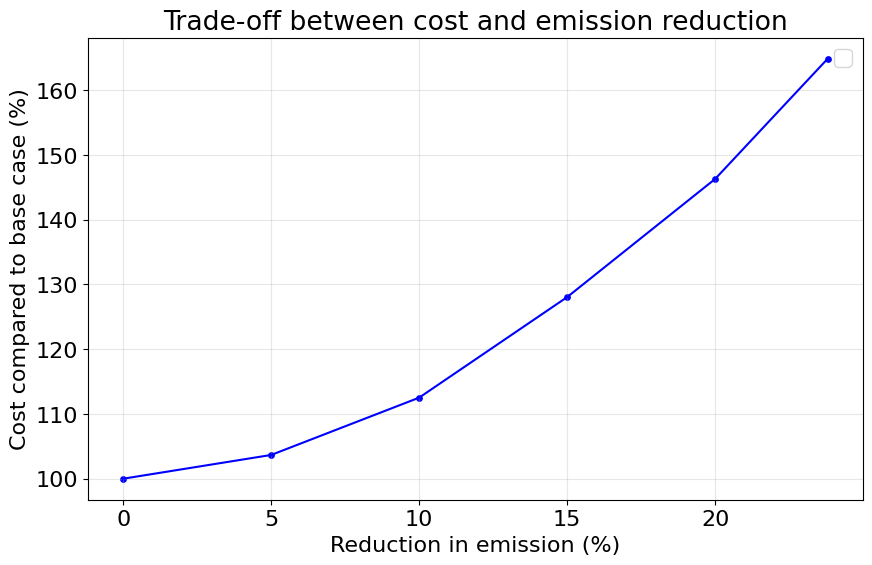

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100, 103.67, 112.52, 128.05, 146.30, 164.86],
        'x_': [0, 5, 10 , 15, 20, 23.8],
        'color': 'blue',
        'label': ''
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction')
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [13]:
l=185.2020301333821
h=200.39398022244458
c=194.11334415998257

In [14]:
100*(1-l/h)

7.581041143151546

In [15]:
100*(1-c/h)

3.1341440773272056

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_14328\2874220998.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.89))


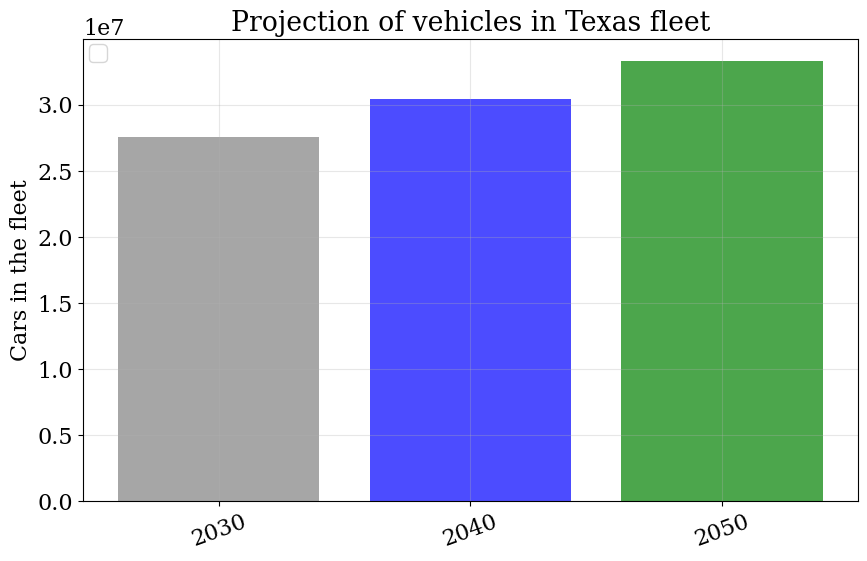

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define data
labels = ['2030', '2040', '2050']
cars = [27580168.0, 30440888.3, 33301608.6]  # Cost compared to base case (%)

x = np.arange(len(labels))  # X-axis positions

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot cost as bar chart on primary y-axis
bars = ax1.bar(x, cars, color=['gray', 'blue', 'green'], label='', alpha=0.7)
ax1.set_ylabel('Cars in the fleet', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)

# Title and grid
plt.title('Projection of vehicles in Texas fleet')
ax1.grid(alpha=0.3)

# Legends
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.89))
plt.rcdefaults()
plt.show()

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_14328\1834317396.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.89))


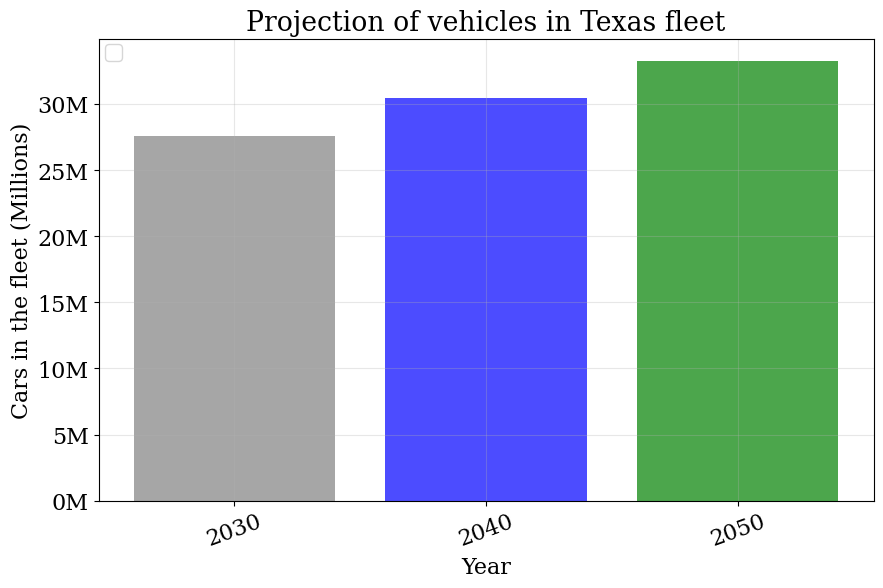

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
import matplotlib.ticker as ticker

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define data
labels = ['2030', '2040', '2050']
cars = [27580168.0, 30440888.3, 33301608.6]  # Number of cars in the fleet

x = np.arange(len(labels))  # X-axis positions

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot cost as bar chart on primary y-axis
bars = ax1.bar(x, cars, color=['gray', 'blue', 'green'], label='', alpha=0.7)
ax1.set_ylabel('Cars in the fleet (Millions)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)

# Format y-axis labels in millions
def millions_formatter(x, pos):
    return f'{x / 1e6:.0f}M'  # Converts numbers to "27M", "30M", etc.

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

# Title and grid
plt.title('Projection of vehicles in Texas fleet')
ax1.grid(alpha=0.3)
plt.xlabel('Year')
# Legends
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.89))
plt.rcdefaults()
plt.show()


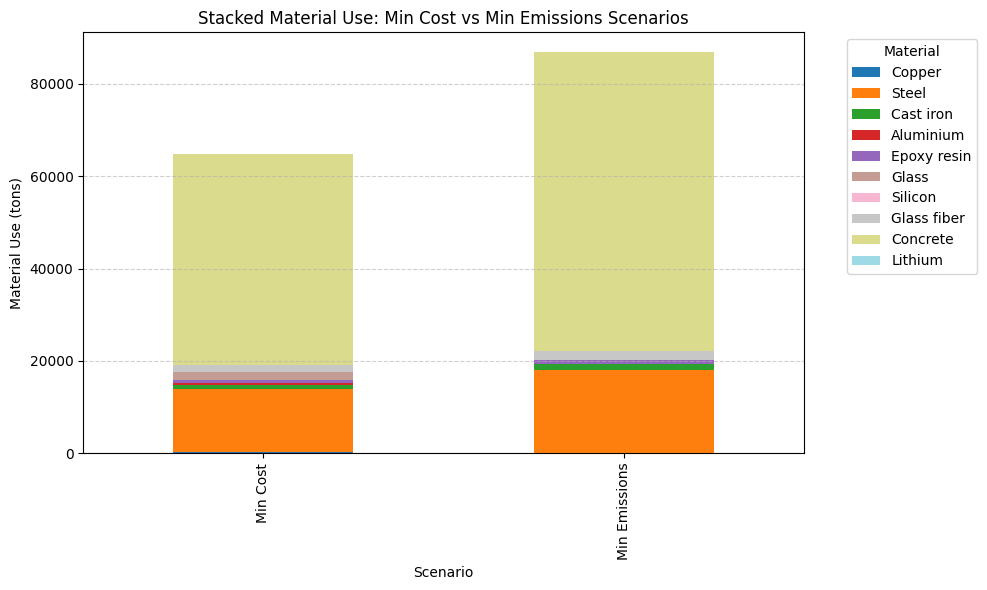

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Define material intensities
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

# Scenario capacities (MW)
scenarios = {
    "Min Cost": {"Wind": 112.08, "PV": 23.50, "Storage": 18.58},
    "Min Emissions": {"Wind": 162.15, "PV": 0.0, "Storage": 80.07}
}

# Compute total materials per scenario
materials = {}
for label, caps in scenarios.items():
    total = {}
    for mat in set(wind_materials) | set(pv_materials) | set(storage_materials):
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += caps['Wind'] * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += caps['PV'] * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += caps['Storage'] * storage_materials[mat]
    materials[label] = total

# Create DataFrame
df = pd.DataFrame(materials)

# Plot
df.T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title("Stacked Material Use: Min Cost vs Min Emissions Scenarios")
plt.ylabel("Material Use (tons)")
plt.xlabel("Scenario")
plt.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


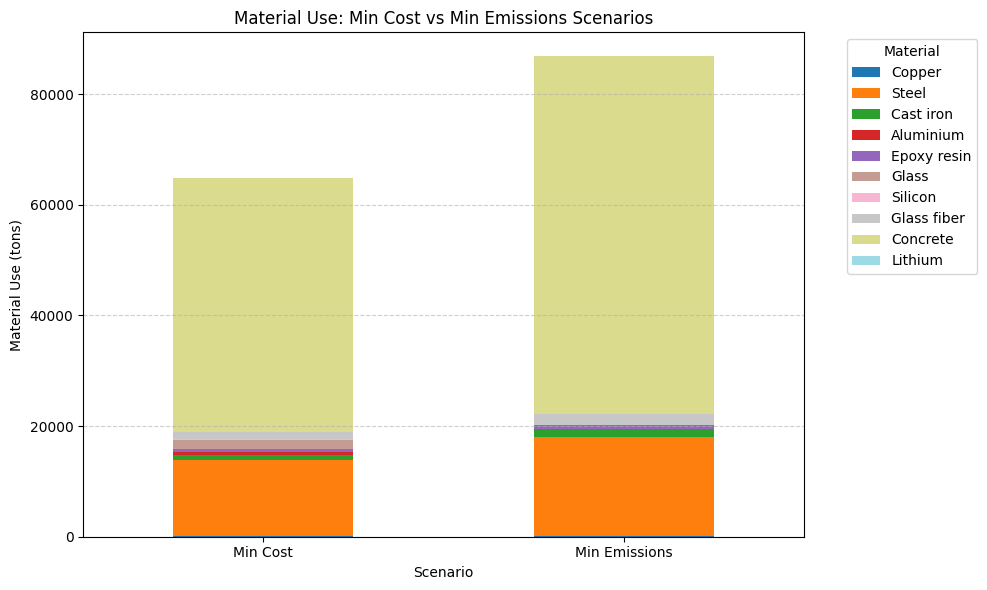

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Define material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

# Scenario capacities (MW)
scenarios = {
    "Min Cost": {"Wind": 112.08, "PV": 23.50, "Storage": 18.58},
    "Min Emissions": {"Wind": 162.15, "PV": 0.0, "Storage": 80.07}
}

# Compute total materials per scenario
materials = {}
for label, caps in scenarios.items():
    total = {}
    for mat in set(wind_materials) | set(pv_materials) | set(storage_materials):
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += caps['Wind'] * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += caps['PV'] * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += caps['Storage'] * storage_materials[mat]
    materials[label] = total

# Create DataFrame
df = pd.DataFrame(materials)

# Plot
df.T.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Material Use: Min Cost vs Min Emissions Scenarios")
plt.ylabel("Material Use (tons)")
plt.xlabel("Scenario")
plt.xticks(rotation=0)  # Keep x-axis labels upright
plt.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


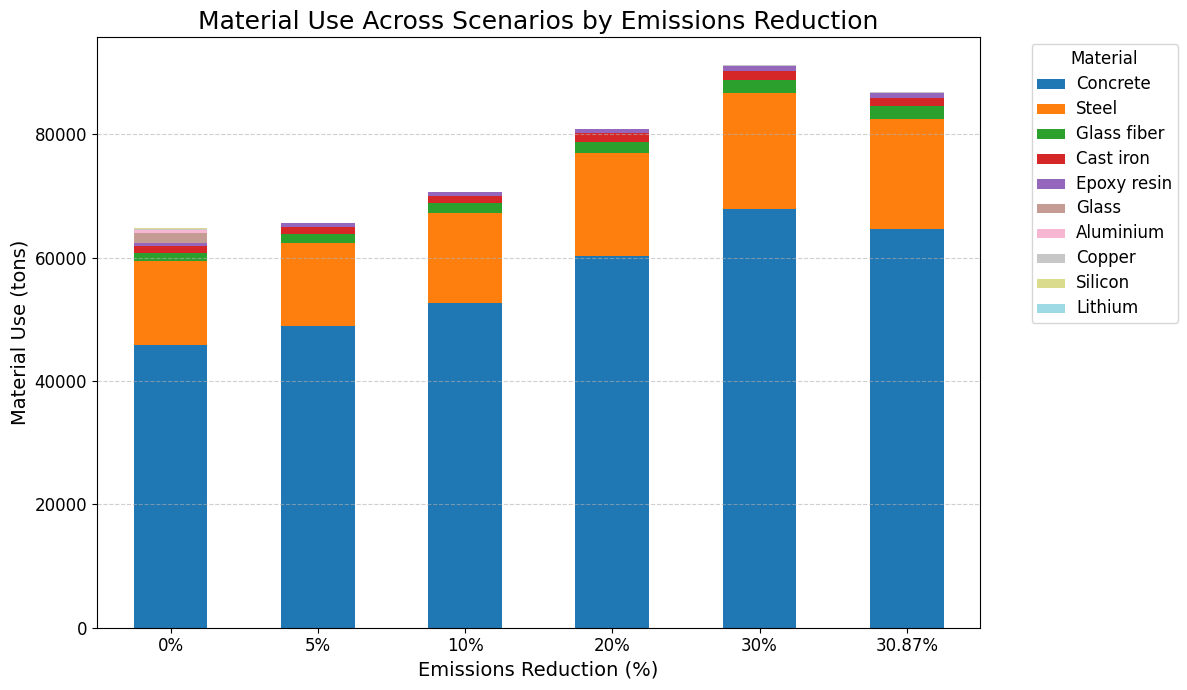

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

# Capacities for scenarios (wind, pv, storage)
capacity_list = [
    (112.08, 23.50, 18.58),
    (122.59, 0, 32.03),
    (132.15, 0, 34.53),
    (151.28, 0, 39.52),
    (170.40, 0, 44.52),
    (162.15, 0, 80.07)
]

# Emissions reductions for each scenario (%)
emissions_reduction = [0, 5, 10, 20, 30, 30.87]

# Calculate total materials for each scenario
materials = {}
for i, (wind_cap, pv_cap, storage_cap) in enumerate(capacity_list, 1):
    total = {}
    all_mats = set(wind_materials) | set(pv_materials) | set(storage_materials)
    for mat in all_mats:
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += wind_cap * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += pv_cap * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += storage_cap * storage_materials[mat]
    materials[f"Scenario {i}"] = total

# Create DataFrame and sort materials by total descending for consistent stacking
df = pd.DataFrame(materials)
df = df.loc[df.sum(axis=1).sort_values(ascending=False).index]

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot stacked bars
df.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')

ax1.set_ylabel("Material Use (tons)", fontsize=14)
ax1.set_xlabel("Emissions Reduction (%)", fontsize=14)

# Replace x-axis labels with emissions reduction values (formatted as percentages)
ax1.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax1.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=12)
plt.setp(legend.get_texts(), fontsize=12)

plt.title("Material Use Across Scenarios by Emissions Reduction", fontsize=18)
plt.tight_layout()
plt.show()


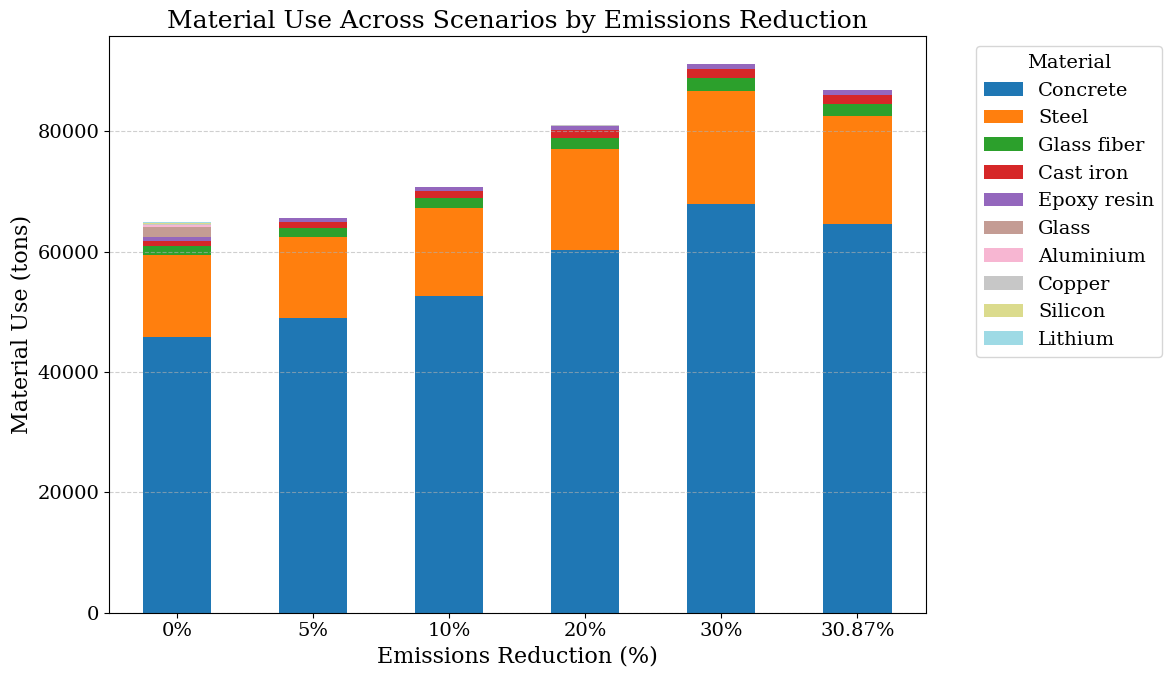

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Set global font properties with rcParams
plt.rcParams.update({
    'font.size': 14,            # Base font size for everything
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 16,       # Axis label font size
    'xtick.labelsize': 14,      # X tick labels font size
    'ytick.labelsize': 14,      # Y tick labels font size
    'legend.fontsize': 14,      # Legend font size
    'font.family': 'serif'      # Example: use serif font family, can be 'sans-serif', 'monospace', etc.
})

# Material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

# Capacities for scenarios (wind, pv, storage)
capacity_list = [
    (112.08, 23.50, 18.58),
    (122.59, 0, 32.03),
    (132.15, 0, 34.53),
    (151.28, 0, 39.52),
    (170.40, 0, 44.52),
    (162.15, 0, 80.07)
]

# Emissions reductions for each scenario (%)
emissions_reduction = [0, 5, 10, 20, 30, 30.87]

# Calculate total materials for each scenario
materials = {}
for i, (wind_cap, pv_cap, storage_cap) in enumerate(capacity_list, 1):
    total = {}
    all_mats = set(wind_materials) | set(pv_materials) | set(storage_materials)
    for mat in all_mats:
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += wind_cap * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += pv_cap * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += storage_cap * storage_materials[mat]
    materials[f"Scenario {i}"] = total

# Create DataFrame and sort materials by total descending for consistent stacking
df = pd.DataFrame(materials)
df = df.loc[df.sum(axis=1).sort_values(ascending=False).index]

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot stacked bars
df.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')

ax1.set_ylabel("Material Use (tons)")
ax1.set_xlabel("Emissions Reduction (%)")

# Replace x-axis labels with emissions reduction values (formatted as percentages)
ax1.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax1.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=14)
plt.setp(legend.get_texts(), fontsize=14)

plt.title("Material Use Across Scenarios by Emissions Reduction")

plt.tight_layout()
plt.show()


In [4]:
# ⚠️ Replace these with your actual GWP (kg CO₂ eq./ton)
gwp_factors = {
    "Steel": 2121.15,        # example → 1.85 t CO₂/ton
    "Cast iron": 1759.71,
    "Concrete": 120.04,
    "Epoxy resin": 5508.8,
    "Glass fiber": 4041,
    "Glass": 1118.5,
    "Aluminium": 16707,
    "Silicon": 98646.7,     # your poly-Si GWP value
    "Copper": 8660.4,
    "Lithium": 2800
}


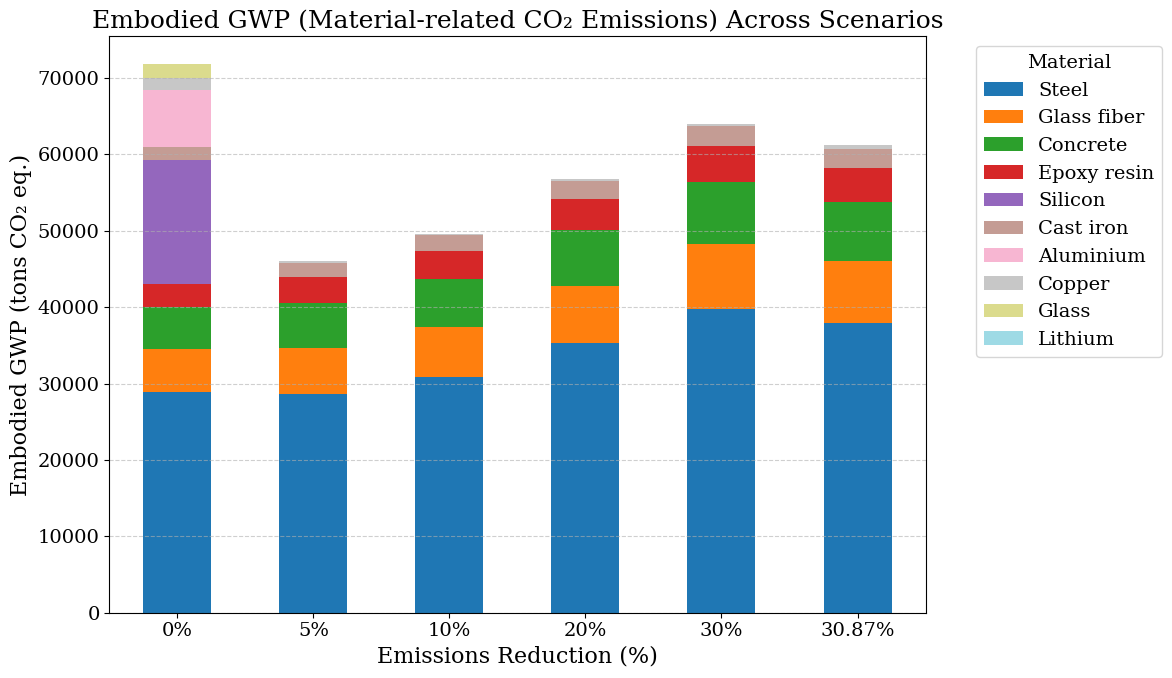

In [5]:
# --- Compute embodied GWP (tons CO₂ eq.) per scenario ---
gwp_results = {}
for scenario, mats in materials.items():
    total_gwp = {}
    for mat, tons_used in mats.items():
        factor_kg = gwp_factors.get(mat, 0)        # kg CO₂ eq / ton material
        total_gwp[mat] = tons_used * factor_kg / 1000  # convert to tons CO₂ eq
    gwp_results[scenario] = total_gwp

# --- Convert to DataFrame and sort materials by total descending ---
df_gwp = pd.DataFrame(gwp_results)
df_gwp = df_gwp.loc[df_gwp.sum(axis=1).sort_values(ascending=False).index]

# --- Plot embodied GWP ---
fig, ax2 = plt.subplots(figsize=(12, 7))
df_gwp.T.plot(kind='bar', stacked=True, ax=ax2, colormap='tab20')

ax2.set_ylabel("Embodied GWP (tons CO₂ eq.)")
ax2.set_xlabel("Emissions Reduction (%)")
ax2.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax2.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=14)
plt.setp(legend.get_texts(), fontsize=14)

plt.title("Embodied GWP (Material-related CO₂ Emissions) Across Scenarios")

plt.tight_layout()
plt.show()


In [2]:
# Compute embodied GWP for each scenario
gwp_results = {}
for scenario, mats in materials.items():
    total_gwp = {}
    for mat, tons_used in mats.items():
        factor_kg = gwp_factors.get(mat, 0)       # kg CO₂ eq./ton material
        total_gwp[mat] = tons_used * factor_kg / 1000  # → tons CO₂ eq.
    gwp_results[scenario] = total_gwp

# Create DataFrame and sort for consistent stacking
df_gwp = pd.DataFrame(gwp_results)
df_gwp = df_gwp.loc[df_gwp.sum(axis=1).sort_values(ascending=False).index]


NameError: name 'materials' is not defined

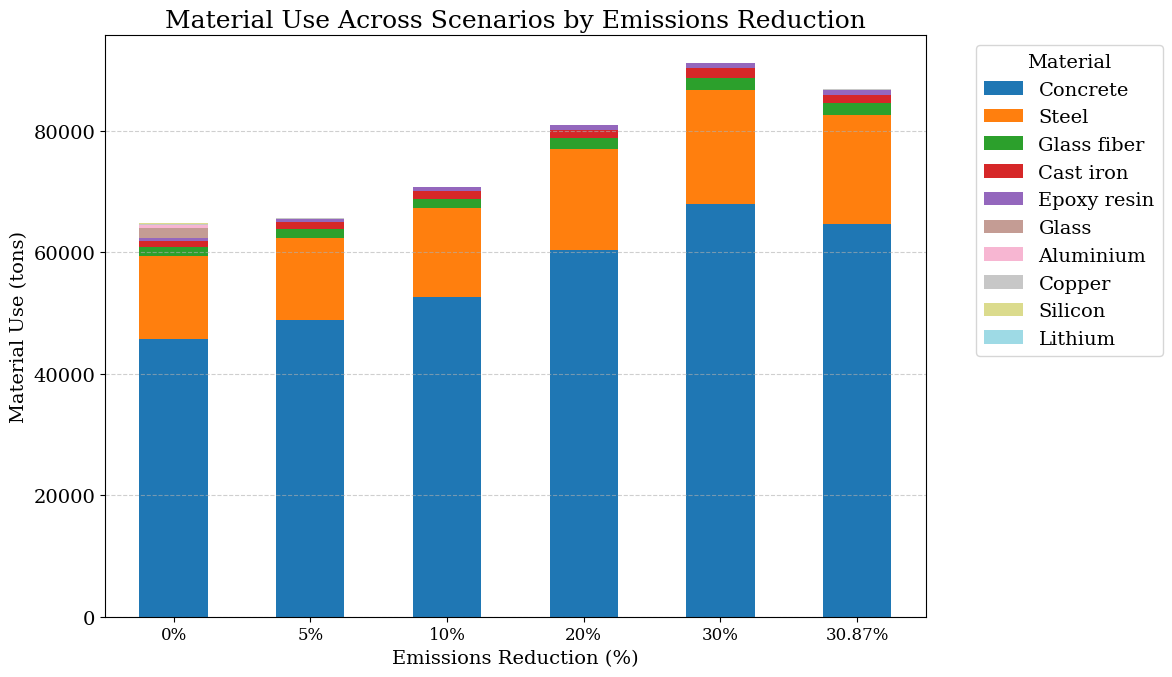

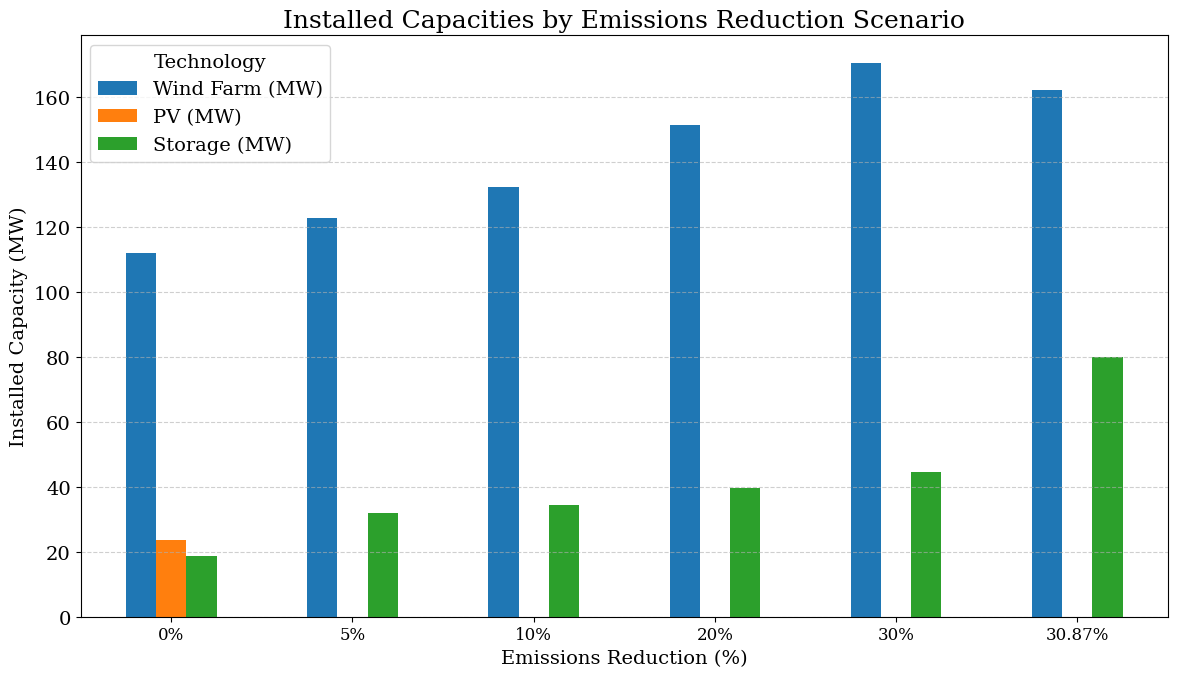

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

# Capacities for scenarios (wind, pv, storage)
capacity_list = [
    (112.08, 23.50, 18.58),
    (122.59, 0, 32.03),
    (132.15, 0, 34.53),
    (151.28, 0, 39.52),
    (170.40, 0, 44.52),
    (162.15, 0, 80.07)
]

emissions_reduction = [0, 5, 10, 20, 30, 30.87]

# Calculate total materials for each scenario
materials = {}
for i, (wind_cap, pv_cap, storage_cap) in enumerate(capacity_list, 1):
    total = {}
    all_mats = set(wind_materials) | set(pv_materials) | set(storage_materials)
    for mat in all_mats:
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += wind_cap * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += pv_cap * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += storage_cap * storage_materials[mat]
    materials[f"Scenario {i}"] = total

# Create DataFrame for materials and sort for stacking
df_materials = pd.DataFrame(materials)
df_materials = df_materials.loc[df_materials.sum(axis=1).sort_values(ascending=False).index]

# ---- Plot 1: Material Use stacked bar plot ----
fig, ax1 = plt.subplots(figsize=(12, 7))

df_materials.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')

ax1.set_ylabel("Material Use (tons)", fontsize=14)
ax1.set_xlabel("Emissions Reduction (%)", fontsize=14)
ax1.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0, fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax1.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=14)
plt.setp(legend.get_texts(), fontsize=14)

plt.title("Material Use Across Scenarios by Emissions Reduction", fontsize=18)
plt.tight_layout()
plt.show()

# ---- Plot 2: Installed capacities grouped bar plot ----

# Create DataFrame for capacities
df_caps = pd.DataFrame(capacity_list, columns=['Wind Farm (MW)', 'PV (MW)', 'Storage (MW)'], index=[f"{val}%" for val in emissions_reduction])

fig, ax2 = plt.subplots(figsize=(12, 7))

df_caps.plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

ax2.set_ylabel("Installed Capacity (MW)", fontsize=14)
ax2.set_xlabel("Emissions Reduction (%)", fontsize=14)
ax2.set_xticklabels(df_caps.index, rotation=0, fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

ax2.legend(title="Technology", fontsize=14, title_fontsize=14, loc='upper left')
plt.title("Installed Capacities by Emissions Reduction Scenario", fontsize=18)

plt.tight_layout()
plt.show()


ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (5).

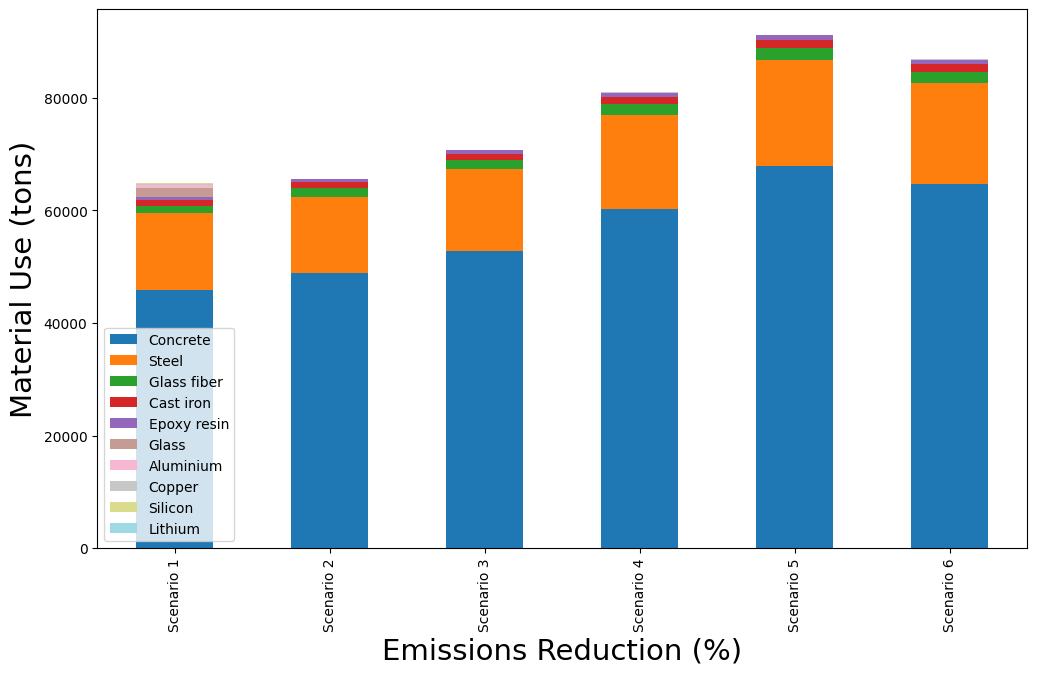

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

capacity_list = [
    (112.08, 23.50, 18.58),
    (122.59, 0, 32.03),
    (132.15, 0, 34.53),
    (151.28, 0, 39.52),
    (170.40, 0, 44.52),
    (162.15, 0, 80.07)
]

emissions_reduction = [0, 27, 44, 58, 71]

materials = {}
for i, (wind_cap, pv_cap, storage_cap) in enumerate(capacity_list, 1):
    total = {}
    all_mats = set(wind_materials) | set(pv_materials) | set(storage_materials)
    for mat in all_mats:
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += wind_cap * wind_materials[mat]
        if mat in pv_materials:
            total[mat] += pv_cap * pv_materials[mat]
        if mat in storage_materials:
            total[mat] += storage_cap * storage_materials[mat]
    materials[f"Scenario {i}"] = total

df_materials = pd.DataFrame(materials)
df_materials = df_materials.loc[df_materials.sum(axis=1).sort_values(ascending=False).index]

# Base font sizes before increase
base_title = 18
base_label = 14
base_tick = 12
base_legend = 14

# Increase by 50%
title_font = int(base_title * 1.5)   # 27
label_font = int(base_label * 1.5)   # 21
tick_font = int(base_tick * 1.5)     # 18
legend_font = int(base_legend * 1.5) # 21

# Plot 1: Material use
fig, ax1 = plt.subplots(figsize=(12, 7))

df_materials.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')

ax1.set_ylabel("Material Use (tons)", fontsize=label_font)
ax1.set_xlabel("Emissions Reduction (%)", fontsize=label_font)
ax1.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0, fontsize=tick_font)
ax1.tick_params(axis='y', labelsize=tick_font)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax1.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=legend_font)
plt.setp(legend.get_texts(), fontsize=legend_font)

plt.title("Material Use Across Scenarios by Emissions Reduction", fontsize=title_font)
plt.tight_layout()
plt.show()

# Plot 2: Installed capacities
df_caps = pd.DataFrame(capacity_list, columns=['Wind Farm (MW)', 'PV (MW)', 'Storage (MW)'], index=[f"{val}%" for val in emissions_reduction])

fig, ax2 = plt.subplots(figsize=(12, 7))

df_caps.plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

ax2.set_ylabel("Installed Capacity (MW)", fontsize=label_font)
ax2.set_xlabel("Emissions Reduction (%)", fontsize=label_font)
ax2.set_xticklabels(df_caps.index, rotation=0, fontsize=tick_font)
ax2.tick_params(axis='y', labelsize=tick_font)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

ax2.legend(title="Technology", fontsize=legend_font, title_fontsize=legend_font, loc='upper left')
plt.title("Installed Capacities by Emissions Reduction Scenario", fontsize=title_font)
plt.tight_layout()
plt.show()


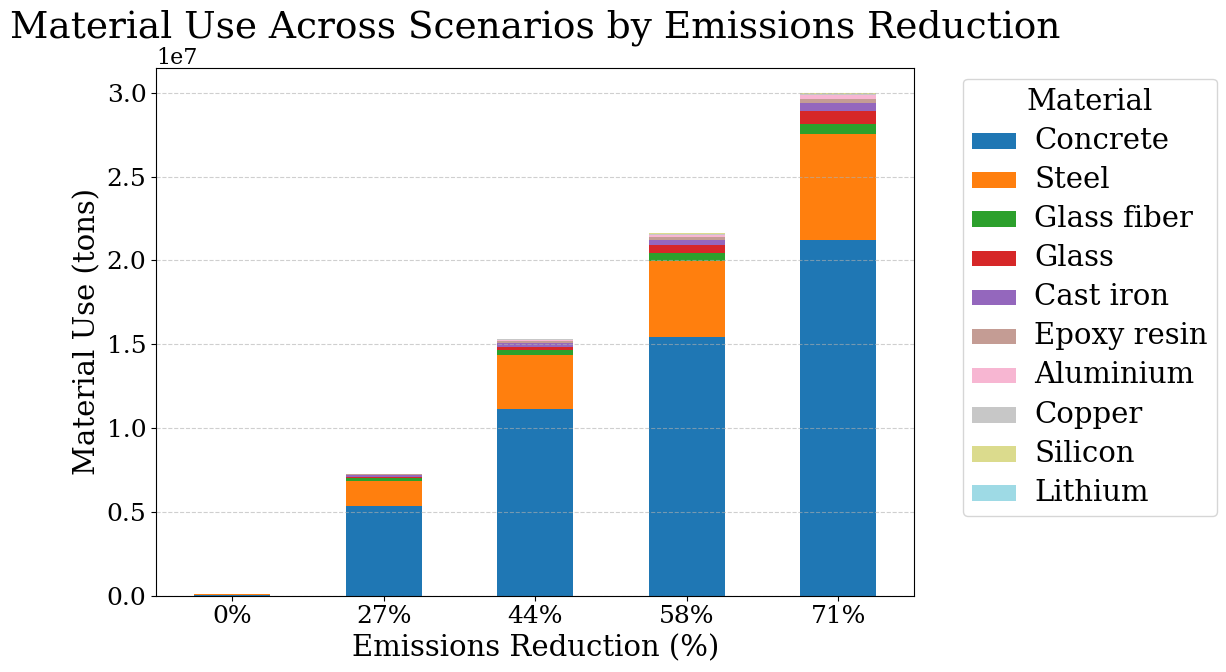

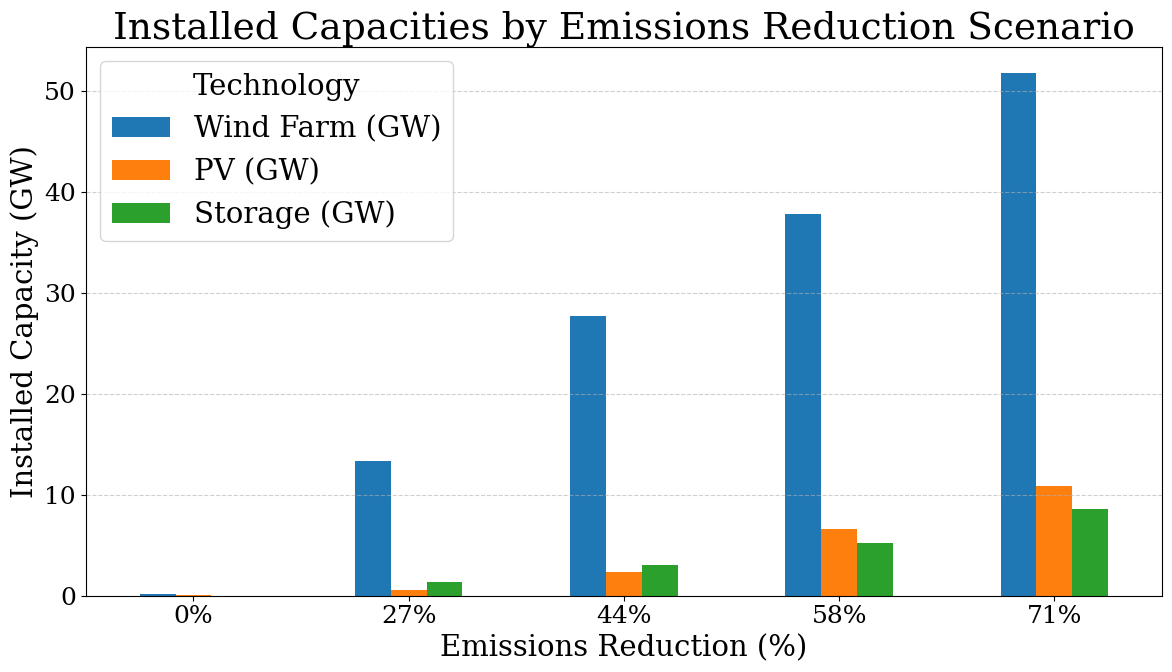

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import rc

rc('font', family='serif', size=16)
rc('mathtext', fontset='cm')  # gives Computer Modern look

# Material intensities (tons/MW)
wind_materials = {
    "Steel": 109.9,
    "Cast iron": 8.805,
    "Concrete": 398.7,
    "Epoxy resin": 5,
    "Glass fiber": 12.2
}

pv_materials = {
    "Glass": 70,
    "Steel": 56,
    "Concrete": 48,
    "Aluminium": 19,
    "Silicon": 7,
    "Copper": 7
}

storage_materials = {
    "Lithium": 0.137,
    "Copper": 0.6497,
    "Steel": 1.165
}

capacity_list = [
    (0.15, 0.03, 0.02),
    (13.37, 0.54, 1.40),
    (27.70, 2.34, 3.07),
    (37.89, 6.60, 5.19),
    (51.86, 10.87, 8.60),
]

emissions_reduction = [0, 27, 44, 58, 71]

materials = {}
for i, (wind_cap, pv_cap, storage_cap) in enumerate(capacity_list, 1):
    total = {}
    all_mats = set(wind_materials) | set(pv_materials) | set(storage_materials)
    for mat in all_mats:
        total[mat] = 0
        if mat in wind_materials:
            total[mat] += wind_cap * wind_materials[mat]*1000
        if mat in pv_materials:
            total[mat] += pv_cap * pv_materials[mat]*1000
        if mat in storage_materials:
            total[mat] += storage_cap * storage_materials[mat]*1000
    materials[f"Scenario {i}"] = total

df_materials = pd.DataFrame(materials)
df_materials = df_materials.loc[df_materials.sum(axis=1).sort_values(ascending=False).index]

# Base font sizes before increase
base_title = 18
base_label = 14
base_tick = 12
base_legend = 14

# Increase by 50%
title_font = int(base_title * 1.5)   # 27
label_font = int(base_label * 1.5)   # 21
tick_font = int(base_tick * 1.5)     # 18
legend_font = int(base_legend * 1.5) # 21

# Plot 1: Material use
fig, ax1 = plt.subplots(figsize=(12, 7))

df_materials.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')

ax1.set_ylabel("Material Use (tons)", fontsize=label_font)
ax1.set_xlabel("Emissions Reduction (%)", fontsize=label_font)
ax1.set_xticklabels([f"{val}%" for val in emissions_reduction], rotation=0, fontsize=tick_font)
ax1.tick_params(axis='y', labelsize=tick_font)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

legend = ax1.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=legend_font)
plt.setp(legend.get_texts(), fontsize=legend_font)

plt.title("Material Use Across Scenarios by Emissions Reduction", fontsize=title_font)
plt.tight_layout()
plt.show()

# Plot 2: Installed capacities
df_caps = pd.DataFrame(capacity_list, columns=['Wind Farm (GW)', 'PV (GW)', 'Storage (GW)'], index=[f"{val}%" for val in emissions_reduction])

fig, ax2 = plt.subplots(figsize=(12, 7))

df_caps.plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

ax2.set_ylabel("Installed Capacity (GW)", fontsize=label_font)
ax2.set_xlabel("Emissions Reduction (%)", fontsize=label_font)
ax2.set_xticklabels(df_caps.index, rotation=0, fontsize=tick_font)
ax2.tick_params(axis='y', labelsize=tick_font)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

ax2.legend(title="Technology", fontsize=legend_font, title_fontsize=legend_font, loc='upper left')
plt.title("Installed Capacities by Emissions Reduction Scenario", fontsize=title_font)
plt.tight_layout()
plt.rcdefaults()
plt.show()
